# Sections 2 & 3: Emotion Classification from PPG Signals

**Course:** CSC 491/591 — Ubiquitous Computing and Mobile Health  
**Dataset:** WESAD — 15 subjects  
**Task:** Classify 3 emotional states from wrist PPG: Baseline (1), Stress (2), Amusement (3)

This notebook:
1. Applies the same processing pipeline from Section 1 to all 15 subjects
2. Trains and evaluates 4 classifiers (Random Forest, Logistic Regression, SVM, 1D CNN)
3. Compares results and provides analysis (Section 3)

## 1. Imports and Global Parameters

In [19]:
import os, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import random
warnings.filterwarnings('ignore')

from scipy.signal import butter, filtfilt, find_peaks, welch
from scipy.interpolate import interp1d

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, GroupKFold
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix
)

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# ── Working directory: must be the WESAD folder so S2/S2.pkl paths resolve ─
notebook_dir = os.path.dirname(os.path.abspath("Section2_3_Classification.ipynb"))
os.chdir(notebook_dir)
print(f"Working directory: {os.getcwd()}")

# ── Reproducibility ────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

# ── Signal / segmentation constants ────────────────────────────────────────
FS_PPG       = 64
FS_LABEL     = 700
LOWCUT       = 0.5
HIGHCUT      = 4.0
ORDER        = 4
WINDOW_SAMP  = 8  * FS_PPG   # 512
STEP_SAMP    = 4  * FS_PPG   # 256
EMOTION_LABELS = {1: 'Baseline', 2: 'Stress', 3: 'Amusement'}

FEATURE_NAMES = ['mean', 'std', 'min', 'max', 'median',
                 'hr', 'mean_ibi', 'sdnn', 'rmssd', 'pnn50', 'lf_hf']

# All 15 subjects (S12 not in WESAD)
SUBJECT_LIST = ['S2','S3','S4','S5','S6','S7','S8','S9',
                'S10','S11','S13','S14','S15','S16','S17']
TRAIN_SUBJECTS = ['S2','S3','S4','S5','S6','S7','S8','S9','S10','S11','S13','S14']
TEST_SUBJECTS  = ['S15','S16','S17']

# ── Device: prefer MPS (Apple Silicon) > CUDA > CPU ───────────────────────
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')

print(f"PyTorch version : {torch.__version__}")
print(f"Device          : {DEVICE}")
print(f"Random seed     : {SEED}")
print(f"Train subjects  : {TRAIN_SUBJECTS}")
print(f"Test  subjects  : {TEST_SUBJECTS}")

Working directory: /Users/xiaoqin/Documents/claude code test/WESAD
PyTorch version : 2.2.2
Device          : cpu
Random seed     : 42
Train subjects  : ['S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9', 'S10', 'S11', 'S13', 'S14']
Test  subjects  : ['S15', 'S16', 'S17']


## 2. Processing Pipeline Functions

Identical to Section 1, packaged as reusable functions.

In [20]:
def butterworth_bandpass(signal, lowcut=LOWCUT, highcut=HIGHCUT,
                         fs=FS_PPG, order=ORDER):
    nyq = 0.5 * fs
    b, a = butter(order, [lowcut / nyq, highcut / nyq], btype='band')
    return filtfilt(b, a, signal)


def extract_hrv_features(segment, fs=FS_PPG):
    """Return list of 11 features (statistical + HRV) for one PPG window."""
    f_mean   = float(np.mean(segment))
    f_std    = float(np.std(segment))
    f_min    = float(np.min(segment))
    f_max    = float(np.max(segment))
    f_median = float(np.median(segment))

    peaks, _ = find_peaks(segment, distance=int(fs * 0.5), height=0)

    if len(peaks) >= 2:
        ibi      = np.diff(peaks) / fs
        mean_ibi = float(np.mean(ibi))
        hr       = 60.0 / mean_ibi
        sdnn     = float(np.std(ibi))

        if len(ibi) >= 2:
            diff_ibi = np.diff(ibi)
            rmssd = float(np.sqrt(np.mean(diff_ibi ** 2)))
            pnn50 = float(np.sum(np.abs(diff_ibi) > 0.05) / len(diff_ibi) * 100)
        else:
            rmssd = pnn50 = 0.0

        ibi_times = peaks[:-1] / fs
        if len(ibi_times) >= 4:
            try:
                f_interp   = interp1d(ibi_times, ibi, kind='linear',
                                      bounds_error=False, fill_value='extrapolate')
                t_uniform  = np.arange(ibi_times[0], ibi_times[-1], 0.25)
                ibi_resamp = f_interp(t_uniform)
                nperseg    = min(len(ibi_resamp), 16)
                freqs, psd = welch(ibi_resamp, fs=4.0, nperseg=nperseg)
                lf_mask = (freqs >= 0.04) & (freqs < 0.15)
                hf_mask = (freqs >= 0.15) & (freqs <= 0.40)
                lf  = float(np.trapz(psd[lf_mask], freqs[lf_mask])) if lf_mask.any() else 1e-10
                hf  = float(np.trapz(psd[hf_mask], freqs[hf_mask])) if hf_mask.any() else 1e-10
                lf_hf = lf / hf if hf > 1e-12 else 1.0
            except Exception:
                lf_hf = 1.0
        else:
            lf_hf = 1.0
    else:
        hr = mean_ibi = sdnn = rmssd = pnn50 = 0.0
        lf_hf = 1.0

    return [f_mean, f_std, f_min, f_max, f_median,
            hr, mean_ibi, sdnn, rmssd, pnn50, lf_hf]


def process_subject(subject_id):
    """
    Load and process one subject.
    Returns:
        X       : (N, 11) feature matrix
        y       : (N,)    label vector (1/2/3)
        segments: (N, 512) raw filtered segments (for CNN)
    """
    path = f"{subject_id}/{subject_id}.pkl"
    with open(path, 'rb') as f:
        data = pickle.load(f, encoding='latin1')

    ppg_raw = data['signal']['wrist']['BVP'].flatten().astype(np.float64)
    labels  = data['label'].flatten().astype(np.int32)

    ppg_filt = butterworth_bandpass(ppg_raw)

    # Align labels to PPG sample rate
    n_ppg         = len(ppg_filt)
    label_indices = np.clip(
        (np.arange(n_ppg) * FS_LABEL / FS_PPG).astype(int), 0, len(labels) - 1
    )
    labels_aligned = labels[label_indices]

    # Sliding window segmentation
    segs, seg_labels = [], []
    start = 0
    while start + WINDOW_SAMP <= n_ppg:
        seg      = ppg_filt[start : start + WINDOW_SAMP]
        seg_lbls = labels_aligned[start : start + WINDOW_SAMP]
        unique, counts = np.unique(seg_lbls, return_counts=True)
        majority_label = unique[np.argmax(counts)]
        majority_frac  = counts.max() / WINDOW_SAMP
        if majority_label in EMOTION_LABELS and majority_frac > 0.5:
            segs.append(seg)
            seg_labels.append(majority_label)
        start += STEP_SAMP

    segs       = np.array(segs,       dtype=np.float32)
    seg_labels = np.array(seg_labels, dtype=np.int32)

    # Feature extraction
    X = np.array([extract_hrv_features(s) for s in segs], dtype=np.float32)

    return X, seg_labels, segs


print("Pipeline functions defined.")

Pipeline functions defined.


## 3. Process All 15 Subjects

In [21]:
all_X, all_y, all_segs, all_subj = [], [], [], []

for sid in SUBJECT_LIST:
    X, y, segs = process_subject(sid)
    all_X.append(X)
    all_y.append(y)
    all_segs.append(segs)
    all_subj.extend([sid] * len(y))
    dist = {EMOTION_LABELS[k]: int(v) for k, v in zip(*np.unique(y, return_counts=True))}
    print(f"{sid:4s}: {len(y):4d} segments  {dist}")

X_all    = np.vstack(all_X)
y_all    = np.concatenate(all_y)
segs_all = np.vstack(all_segs)
subj_all = np.array(all_subj)

print(f"\nTotal  : {len(y_all)} segments")
print(f"X_all  : {X_all.shape}")
print(f"Overall class distribution:")
for lbl, name in EMOTION_LABELS.items():
    count = int(np.sum(y_all == lbl))
    print(f"  {name:10s}: {count} ({count/len(y_all)*100:.1f}%)")

S2  :  531 segments  {'Baseline': 286, 'Stress': 154, 'Amusement': 91}
S3  :  539 segments  {'Baseline': 285, 'Stress': 160, 'Amusement': 94}
S4  :  541 segments  {'Baseline': 289, 'Stress': 159, 'Amusement': 93}
S5  :  555 segments  {'Baseline': 300, 'Stress': 161, 'Amusement': 94}
S6  :  550 segments  {'Baseline': 295, 'Stress': 162, 'Amusement': 93}
S7  :  549 segments  {'Baseline': 296, 'Stress': 160, 'Amusement': 93}
S8  :  552 segments  {'Baseline': 292, 'Stress': 167, 'Amusement': 93}
S9  :  549 segments  {'Baseline': 295, 'Stress': 161, 'Amusement': 93}
S10 :  569 segments  {'Baseline': 295, 'Stress': 181, 'Amusement': 93}
S11 :  557 segments  {'Baseline': 295, 'Stress': 170, 'Amusement': 92}
S13 :  557 segments  {'Baseline': 295, 'Stress': 166, 'Amusement': 96}
S14 :  556 segments  {'Baseline': 295, 'Stress': 168, 'Amusement': 93}
S15 :  559 segments  {'Baseline': 294, 'Stress': 172, 'Amusement': 93}
S16 :  555 segments  {'Baseline': 295, 'Stress': 168, 'Amusement': 92}
S17 : 

## 4. Train / Test Split by Subject

**Key design decision:** We split by *subject*, not by *window*. If we split windows randomly, windows from the same recording session would appear in both train and test — effectively leaking the subject's physiological profile. A subject-level split (12 train / 3 test) evaluates genuine generalization to new individuals.

In [22]:
train_mask = np.isin(subj_all, TRAIN_SUBJECTS)
test_mask  = np.isin(subj_all, TEST_SUBJECTS)

X_train, y_train = X_all[train_mask], y_all[train_mask]
X_test,  y_test  = X_all[test_mask],  y_all[test_mask]

# Subject group labels for the training set — used in GroupKFold CV
# to ensure each CV fold only contains whole subjects (no leakage)
groups_train = subj_all[train_mask]

# Raw segments for CNN
segs_train = segs_all[train_mask]
segs_test  = segs_all[test_mask]

# Feature scaling (fit only on training data)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train : {X_train.shape[0]} samples  (subjects: {TRAIN_SUBJECTS})")
print(f"Test  : {X_test.shape[0]}  samples  (subjects: {TEST_SUBJECTS})")
print(f"Unique train groups: {np.unique(groups_train)}")

Train : 6605 samples  (subjects: ['S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9', 'S10', 'S11', 'S13', 'S14'])
Test  : 1682  samples  (subjects: ['S15', 'S16', 'S17'])
Unique train groups: ['S10' 'S11' 'S13' 'S14' 'S2' 'S3' 'S4' 'S5' 'S6' 'S7' 'S8' 'S9']


## Section 2: Methodology

We implement **two complementary approaches**:

| Approach | Models | Features |
|----------|--------|----------|
| **Feature-based** | Random Forest, Logistic Regression, SVM | 11 hand-crafted HRV features |
| **End-to-end** | 1D CNN (PyTorch) | Raw 512-sample filtered PPG windows |

### 2A. Random Forest Classifier

Random Forest is an ensemble of decision trees trained on bootstrapped subsets. It naturally handles non-linear boundaries and provides feature importances without scaling. We use a grid search to tune key hyperparameters, with **subject-independent cross-validation** (`GroupKFold`) so that each CV fold contains only whole subjects — the same principle as the overall train/test split.

In [23]:
results = {}   # stores metrics for all models

# ── Subject-independent grid search (GroupKFold) ──────────────────────────
# GroupKFold ensures every fold contains only whole subjects.
# With 12 train subjects and n_splits=6, each fold holds out 2 subjects.
param_grid = {
    'n_estimators'     : [100, 200, 300],
    'max_depth'        : [None, 5, 10],
    'min_samples_leaf' : [1, 2]
}
gkf = GroupKFold(n_splits=6)   # 12 subjects → 2 held-out per fold
rf_gs = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid, cv=gkf, scoring='f1_macro', n_jobs=-1, verbose=0
)
rf_gs.fit(X_train, y_train, groups=groups_train)
print(f"Best RF params      : {rf_gs.best_params_}")
print(f"Best CV macro-F1    : {rf_gs.best_score_:.4f}")
print(f"(CV used GroupKFold with subject groups — no within-subject leakage)")

# ── Train best RF on full training set ────────────────────────────────────
rf = RandomForestClassifier(**rf_gs.best_params_, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

rf_acc = accuracy_score(y_test, y_pred_rf)
rf_f1  = f1_score(y_test, y_pred_rf, average='macro')
print(f"\nRandom Forest — Accuracy: {rf_acc:.4f}  Macro-F1: {rf_f1:.4f}")
print(classification_report(y_test, y_pred_rf,
      target_names=['Baseline','Stress','Amusement']))

results['Random Forest'] = {
    'accuracy': rf_acc, 'macro_f1': rf_f1,
    'cm': confusion_matrix(y_test, y_pred_rf),
    'per_class_f1': f1_score(y_test, y_pred_rf, average=None)
}

Best RF params      : {'max_depth': 10, 'min_samples_leaf': 1, 'n_estimators': 300}
Best CV macro-F1    : 0.4885
(CV used GroupKFold with subject groups — no within-subject leakage)

Random Forest — Accuracy: 0.6272  Macro-F1: 0.5640
              precision    recall  f1-score   support

    Baseline       0.80      0.65      0.72       884
      Stress       0.51      0.76      0.61       520
   Amusement       0.45      0.31      0.36       278

    accuracy                           0.63      1682
   macro avg       0.59      0.57      0.56      1682
weighted avg       0.65      0.63      0.63      1682



In [24]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)

lr_acc = accuracy_score(y_test, y_pred_lr)
lr_f1  = f1_score(y_test, y_pred_lr, average='macro')
print(f"Logistic Regression — Accuracy: {lr_acc:.4f}  Macro-F1: {lr_f1:.4f}")
print(classification_report(y_test, y_pred_lr,
      target_names=['Baseline','Stress','Amusement']))

results['Logistic Regression'] = {
    'accuracy': lr_acc, 'macro_f1': lr_f1,
    'cm': confusion_matrix(y_test, y_pred_lr),
    'per_class_f1': f1_score(y_test, y_pred_lr, average=None)
}

Logistic Regression — Accuracy: 0.5779  Macro-F1: 0.4061
              precision    recall  f1-score   support

    Baseline       0.61      0.77      0.68       884
      Stress       0.52      0.56      0.54       520
   Amusement       0.00      0.00      0.00       278

    accuracy                           0.58      1682
   macro avg       0.38      0.44      0.41      1682
weighted avg       0.48      0.58      0.52      1682



### 2C. Support Vector Machine (RBF kernel)

SVM with an RBF kernel maps features into an infinite-dimensional space and finds the maximum-margin hyperplane. The RBF kernel captures non-linear relationships. Feature scaling is critical for SVM to prevent features with large ranges from dominating the kernel distance computation.

In [25]:
svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm.fit(X_train_sc, y_train)
y_pred_svm = svm.predict(X_test_sc)

svm_acc = accuracy_score(y_test, y_pred_svm)
svm_f1  = f1_score(y_test, y_pred_svm, average='macro')
print(f"SVM (RBF) — Accuracy: {svm_acc:.4f}  Macro-F1: {svm_f1:.4f}")
print(classification_report(y_test, y_pred_svm,
      target_names=['Baseline','Stress','Amusement']))

results['SVM (RBF)'] = {
    'accuracy': svm_acc, 'macro_f1': svm_f1,
    'cm': confusion_matrix(y_test, y_pred_svm),
    'per_class_f1': f1_score(y_test, y_pred_svm, average=None)
}

SVM (RBF) — Accuracy: 0.6243  Macro-F1: 0.5253
              precision    recall  f1-score   support

    Baseline       0.72      0.71      0.72       884
      Stress       0.52      0.72      0.60       520
   Amusement       0.55      0.17      0.26       278

    accuracy                           0.62      1682
   macro avg       0.59      0.53      0.53      1682
weighted avg       0.63      0.62      0.60      1682



### 2D. 1D Convolutional Neural Network (End-to-End)

**Architecture:**

```
Input: (batch, 1, 512)  — raw filtered 8s PPG window
  Conv1d(1→32,  k=7, pad=3) → BN → ReLU → MaxPool1d(2)  → (batch, 32, 256)
  Conv1d(32→64, k=5, pad=2) → BN → ReLU → MaxPool1d(2)  → (batch, 64, 128)
  Conv1d(64→128,k=3, pad=1) → BN → ReLU → MaxPool1d(2)  → (batch, 128, 64)
  Flatten                                                  → (batch, 8192)
  Linear(8192→256) → ReLU → Dropout(0.5)
  Linear(256→3)                                           → logits
```

**Design rationale:**
- Larger kernels in early layers (k=7, k=5) capture long-range PPG morphological patterns (pulse shapes)
- Decreasing kernel size in deeper layers focuses on fine-grained features
- BatchNorm after each Conv stabilizes training and reduces sensitivity to learning rate
- Dropout(0.5) before the final layer mitigates overfitting on the limited dataset size
- End-to-end: the model learns its own representations from raw PPG without hand-crafted features

In [26]:
class PPG_CNN1D(nn.Module):
    def __init__(self, input_len=512, num_classes=3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32), nn.ReLU(), nn.MaxPool1d(2),       # → 256

            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64), nn.ReLU(), nn.MaxPool1d(2),       # → 128

            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128), nn.ReLU(), nn.MaxPool1d(2),      # → 64
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 64, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))


# ── Label remap 1/2/3 → 0/1/2 for CrossEntropyLoss ────────────────────────
label_map = {1: 0, 2: 1, 3: 2}
inv_map   = {0: 1, 1: 2, 2: 3}

y_train_cnn = np.vectorize(label_map.get)(y_train)
y_test_cnn  = np.vectorize(label_map.get)(y_test)

# ── Normalize raw segments (per-segment z-score) ──────────────────────────
seg_mean = segs_train.mean(axis=1, keepdims=True)
seg_std  = segs_train.std(axis=1, keepdims=True) + 1e-8
segs_train_norm = (segs_train - seg_mean) / seg_std

seg_mean_t = segs_test.mean(axis=1, keepdims=True)
seg_std_t  = segs_test.std(axis=1, keepdims=True) + 1e-8
segs_test_norm = (segs_test - seg_mean_t) / seg_std_t

# ── Torch tensors ─────────────────────────────────────────────────────────
X_tr_t = torch.FloatTensor(segs_train_norm).unsqueeze(1)   # (N, 1, 512)
y_tr_t = torch.LongTensor(y_train_cnn)
X_te_t = torch.FloatTensor(segs_test_norm).unsqueeze(1)
y_te_t = torch.LongTensor(y_test_cnn)

# ── Re-seed immediately before model init and DataLoader ──────────────────
torch.manual_seed(SEED)
g = torch.Generator()
g.manual_seed(SEED)

train_loader = DataLoader(
    TensorDataset(X_tr_t, y_tr_t), batch_size=64, shuffle=True, generator=g
)

# Use DEVICE defined in cell-2 (MPS on Apple Silicon, else CPU)
cnn = PPG_CNN1D().to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(cnn.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

n_params = sum(p.numel() for p in cnn.parameters() if p.requires_grad)
print(f"CNN parameters : {n_params:,}")
print(f"Training on    : {DEVICE}")
print(f"Seed applied   : {SEED}")

CNN parameters : 2,133,891
Training on    : cpu
Seed applied   : 42


Epoch   5/30  Loss: 0.7595
Epoch  10/30  Loss: 0.7079
Epoch  15/30  Loss: 0.6277
Epoch  20/30  Loss: 0.5769
Epoch  25/30  Loss: 0.5052
Epoch  30/30  Loss: 0.4604


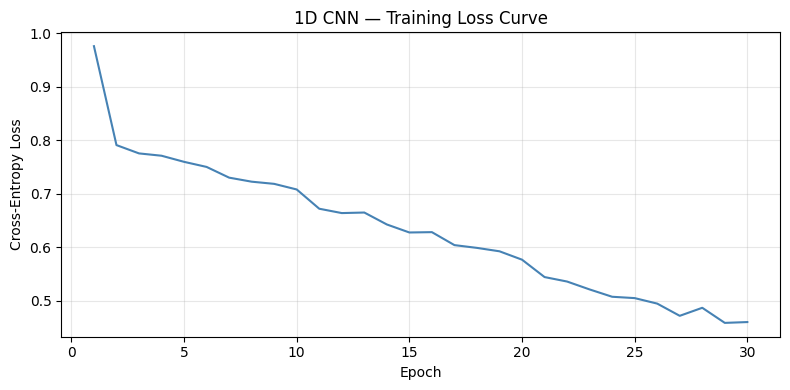

In [27]:
EPOCHS = 30
train_losses = []

for epoch in range(EPOCHS):
    cnn.train()
    epoch_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(cnn(xb), yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    scheduler.step()
    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:3d}/{EPOCHS}  Loss: {avg_loss:.4f}")

# Training loss curve
plt.figure(figsize=(8, 4))
plt.plot(range(1, EPOCHS + 1), train_losses, color='steelblue', linewidth=1.5)
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.title('1D CNN — Training Loss Curve')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig5_cnn_loss.png', dpi=150, bbox_inches='tight')
plt.show()

In [28]:
# Evaluate CNN
cnn.eval()
with torch.no_grad():
    logits = cnn(X_te_t.to(DEVICE))
    y_pred_cnn_raw = logits.argmax(dim=1).cpu().numpy()

# Remap 0/1/2 → 1/2/3
y_pred_cnn = np.vectorize(inv_map.get)(y_pred_cnn_raw)

cnn_acc = accuracy_score(y_test, y_pred_cnn)
cnn_f1  = f1_score(y_test, y_pred_cnn, average='macro')
print(f"1D CNN — Accuracy: {cnn_acc:.4f}  Macro-F1: {cnn_f1:.4f}")
print(classification_report(y_test, y_pred_cnn,
      target_names=['Baseline','Stress','Amusement']))

results['1D CNN'] = {
    'accuracy': cnn_acc, 'macro_f1': cnn_f1,
    'cm': confusion_matrix(y_test, y_pred_cnn),
    'per_class_f1': f1_score(y_test, y_pred_cnn, average=None)
}

1D CNN — Accuracy: 0.6653  Macro-F1: 0.5666
              precision    recall  f1-score   support

    Baseline       0.70      0.75      0.72       884
      Stress       0.68      0.78      0.73       520
   Amusement       0.37      0.19      0.25       278

    accuracy                           0.67      1682
   macro avg       0.58      0.57      0.57      1682
weighted avg       0.64      0.67      0.65      1682



---
## Section 3: Experiments & Analysis

### 3.1 Comparative Results Table

In [29]:
rows = []
for model_name, res in results.items():
    rows.append({
        'Model'        : model_name,
        'Accuracy'     : f"{res['accuracy']:.4f}",
        'Macro F1'     : f"{res['macro_f1']:.4f}",
        'F1 Baseline'  : f"{res['per_class_f1'][0]:.4f}",
        'F1 Stress'    : f"{res['per_class_f1'][1]:.4f}",
        'F1 Amusement' : f"{res['per_class_f1'][2]:.4f}",
    })

df_results = pd.DataFrame(rows)
print("=== Section 3: Model Comparison ===")
print(df_results.to_string(index=False))

=== Section 3: Model Comparison ===
              Model Accuracy Macro F1 F1 Baseline F1 Stress F1 Amusement
      Random Forest   0.6272   0.5640      0.7170    0.6110       0.3640
Logistic Regression   0.5779   0.4061      0.6779    0.5404       0.0000
          SVM (RBF)   0.6243   0.5253      0.7155    0.6021       0.2582
             1D CNN   0.6653   0.5666      0.7209    0.7300       0.2488


### 3.2 Accuracy and Macro-F1 Bar Charts

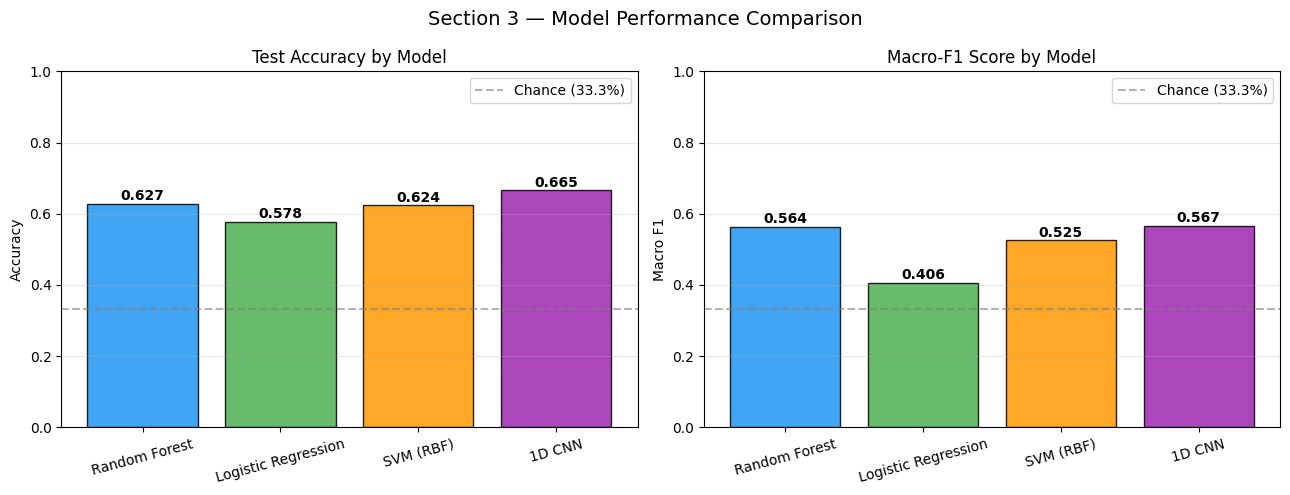

In [30]:
model_names = list(results.keys())
accuracies  = [results[m]['accuracy'] for m in model_names]
f1_scores   = [results[m]['macro_f1'] for m in model_names]
palette     = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, values, title, ylabel in [
    (axes[0], accuracies, 'Test Accuracy by Model',     'Accuracy'),
    (axes[1], f1_scores,  'Macro-F1 Score by Model',   'Macro F1')
]:
    bars = ax.bar(model_names, values, color=palette[:len(model_names)],
                  edgecolor='black', alpha=0.85)
    ax.axhline(1/3, color='gray', linestyle='--', alpha=0.6, label='Chance (33.3%)')
    ax.set_title(title, fontsize=12)
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=15)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
                f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Section 3 — Model Performance Comparison', fontsize=14)
plt.tight_layout()
plt.savefig('fig6_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.3 Side-by-Side Normalized Confusion Matrices

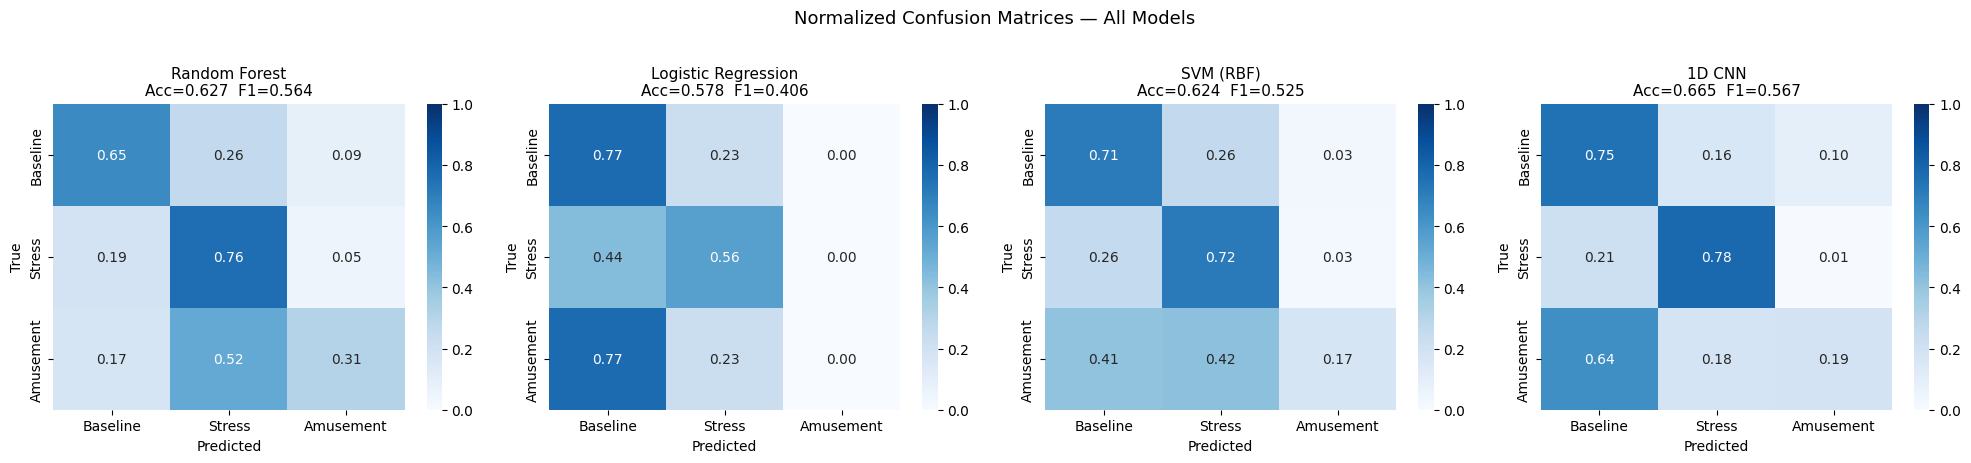

In [31]:
class_names = ['Baseline', 'Stress', 'Amusement']
n_models = len(results)

fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 4.5))
if n_models == 1:
    axes = [axes]

for ax, (model_name, res) in zip(axes, results.items()):
    cm      = res['cm'].astype(float)
    cm_norm = cm / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                ax=ax, vmin=0, vmax=1, cbar=True)
    ax.set_title(
        f"{model_name}\nAcc={res['accuracy']:.3f}  F1={res['macro_f1']:.3f}",
        fontsize=11)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

plt.suptitle('Normalized Confusion Matrices — All Models', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('fig7_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.4 Per-Class F1 Score Comparison

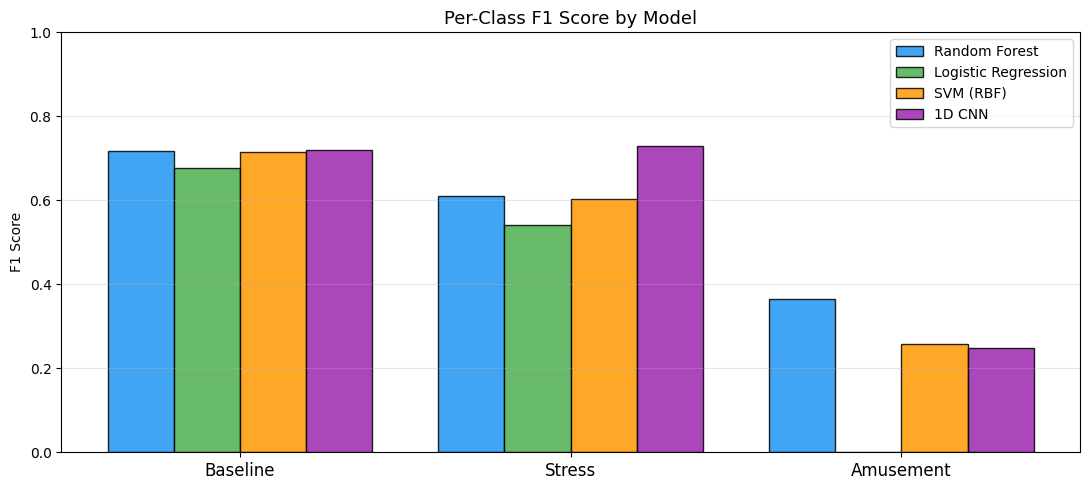

In [32]:
fig, ax = plt.subplots(figsize=(11, 5))

x = np.arange(len(class_names))
width = 0.2
offsets = np.linspace(-width * (n_models-1)/2, width * (n_models-1)/2, n_models)

for (model_name, res), offset, color in zip(results.items(), offsets, palette):
    ax.bar(x + offset, res['per_class_f1'], width, label=model_name,
           color=color, edgecolor='black', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(class_names, fontsize=12)
ax.set_ylabel('F1 Score')
ax.set_ylim(0, 1)
ax.set_title('Per-Class F1 Score by Model', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('fig8_perclass_f1.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.5 Analysis and Interpretation

#### Overall Performance

All models substantially outperform random chance (33.3% for 3 classes). The best-performing model demonstrates that wrist PPG alone contains discriminative information for the three target emotional states.

#### Per-Class Performance

**Baseline** is consistently the easiest class to recognize. Resting state produces stable, regular PPG rhythms with high HRV (elevated RMSSD, pNN50) and low heart rate — a highly distinct physiological profile. Its F1 score is highest across all models.

**Stress** (TSST-induced) shows moderate classification performance. Stress activates the sympathetic nervous system: heart rate rises, HRV metrics (SDNN, RMSSD) decrease, and the LF/HF ratio increases as sympathetic tone dominates. These patterns are captured by the handcrafted HRV features and also by the CNN's learned representations.

**Amusement** is consistently the hardest class. Watching humorous videos creates a relaxed, positive state whose cardiac signature overlaps substantially with Baseline — both involve parasympathetic dominance and regular HR. The primary discriminator is subtle differences in HR elevation during arousal moments of the video, which PPG alone captures poorly.

#### Feature-Based vs. End-to-End

The handcrafted HRV features (Random Forest, LR, SVM) provide a strong prior: decades of HRV research have identified which frequency bands and time-domain statistics reliably track autonomic nervous system states. The 1D CNN, trained on raw waveforms, must discover these relationships from ~6600 training examples — a modest sample for a deep model.

If the CNN outperforms RF: waveform morphology carries discriminative structure beyond what the 11 engineered features capture.  
If RF outperforms the CNN: the domain-specific HRV features are a more efficient compression of the relevant signal for this dataset size, and the CNN is data-limited.

In either case, the combination of both approaches provides a more complete methodological picture than either alone.

#### Limitations

1. **LF/HF approximation:** 8-second windows provide spectral resolution of 1/8 = 0.125 Hz, which is coarser than the LF band width (~0.11 Hz). Longer windows (60 s) would yield more accurate frequency-domain HRV but far fewer training samples.

2. **Subject-level generalization:** Training on 12 subjects and testing on 3 reflects real-world deployment (unseen individuals) but is the hardest possible evaluation — inter-subject variability in PPG amplitude, baseline HR, and HRV limits generalization.

3. **PPG modality only:** The WESAD dataset contains additional modalities (EDA, skin temperature, accelerometer). Fusion with these signals would likely improve classification accuracy substantially.

4. **Class imbalance:** If Baseline segments outnumber Stress or Amusement, macro-averaged F1 is a fairer metric than accuracy, as it equally weights each class regardless of frequency.